In [1]:
import os
import cv2  
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Define the path to the image
folder_path = "C:\\Users\\Lenovo\\OneDrive\\Desktop\\heart_rate_project\\sample_data\\Subject1\\NIR-002"

In [4]:
# Load Imange paths
def get_image_paths(folder_path, max_frames = 500):
    
    files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(".pgm")

    ])

    files = files[:max_frames]

    image_paths = [os.path.join(folder_path, f) for f in files]
    return image_paths

In [5]:
# Load single Image

def load_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return img

In [6]:
# Resize the image  to 64x64

def resize_image(img, size=(64,64)):
    resized = cv2.resize(img, size)
    return resized

In [7]:
#Normalise the Image    
def normalise_image(img):
    img = img / 255.0       
    return img

Frames Shape: (100, 64, 64)
Min Pixel Value: 0.01568627450980392
Max Pixel Value: 0.8313725490196079


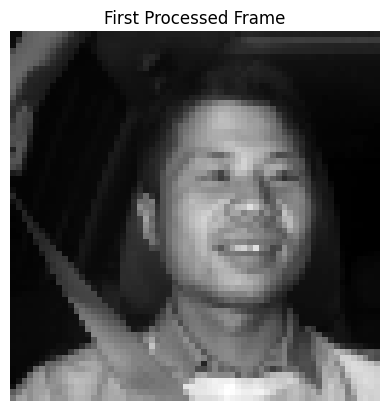

In [10]:
# Complete preprocessing pipeline
def preprocess_image(image_path):
    img = load_image(image_path)
    img = resize_image(img)
    img = normalise_image(img)
    
    return img

# Load multiple frames and preprocess them
def load_and_preprocess_images(folder_path, max_frames=500):
    image_paths = get_image_paths(folder_path, max_frames)

    frames = []
    for path in image_paths:
        preprocessed = preprocess_image(path)
        frames.append(preprocessed)
   
    frames = np.array(frames)
    return frames

# Display sample frames
def display_sample_frames(frames, title="Sample Frames"):
    plt.imshow(frames, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Main execution
if __name__ == "__main__":

    folder_path = "C:\\Users\\Lenovo\\OneDrive\\Desktop\\heart_rate_project\\sample_data\\Subject1\\NIR-002"
    frames = load_and_preprocess_images(folder_path, max_frames=100)

    print("Frames Shape:", frames.shape)

    print("Min Pixel Value:", frames.min())

    print("Max Pixel Value:", frames.max())
    display_sample_frames(frames[0], title="First Processed Frame")


    